# Exploring the Data

In [245]:
import pandas as pd

In [246]:
df = pd.read_csv('messy_orders.csv')
df.head()

,order_id,order_date,customer_name,customer_email,product_category,product_name,quantity,unit_price,discount_percent,shipping_cost,region,payment_method,order_status
0,100810,21/03/2025,Mariam Khan,mariam.khan@hotmail.com,Beauty,Sunscreen SPF50,1,$17.45,0.0,11.08,West,PayPal,completed
1,100489,"February 28, 2025",Maria Sheikh,maria.sheikh@hotmail.com,Home & Kitchen,Cookware Set,6,136.42,0.0,4.14,South,paypal,pending
2,100799,2025-06-14,Usman Smith,usman.smith@hotmail.com,Electronic,Laptop Stand,4,24.44,0.0,6.07,north,Debit Card,COMPLETED
3,100680,"February 06, 2025",Omar Wilson,omar.wilson@gmail.com,clothing,Winter Coat,3 units,$117.21,0.0,5.02,North,PayPal,Returned
4,100898,2025/04/21,Zain Ali,zain.aligmail.com,beauty,Perfume 50ml,3,$52.15,10.0,6.90,SOUTH,debit card,returned


In [247]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1442 non-null   int64  
 1   order_date        1442 non-null   str    
 2   customer_name     1442 non-null   str    
 3   customer_email    1364 non-null   str    
 4   product_category  1442 non-null   str    
 5   product_name      1442 non-null   str    
 6   quantity          1331 non-null   str    
 7   unit_price        1377 non-null   str    
 8   discount_percent  1374 non-null   float64
 9   shipping_cost     1359 non-null   float64
 10  region            1387 non-null   str    
 11  payment_method    1400 non-null   str    
 12  order_status      1442 non-null   str    
dtypes: float64(2), int64(1), str(10)
memory usage: 146.6 KB


In [248]:
df.isnull().sum()

order_id              0
order_date            0
customer_name         0
customer_email       78
product_category      0
product_name          0
quantity            111
unit_price           65
discount_percent     68
shipping_cost        83
region               55
payment_method       42
order_status          0
dtype: int64

# Cleaning the Data

## Text Normalization

In [249]:
df["product_category"] = df["product_category"].str.lower()
df["product_category"] = df["product_category"].str.strip()

mask = df["product_category"].str.contains("home|kitchen")
df.loc[mask, "product_category"] = "home and kitchen"

mask = df["product_category"].str.contains("sports|outdoors")
df.loc[mask, "product_category"] = "sports and outdoors"

mask = df["product_category"].str.contains("electronic")
df.loc[mask, "product_category"] = "electronics"

df["region"] = df["region"].str.lower()
df["region"] = df["region"].str.strip()

north_mask = df["region"].str.startswith("n")
df.loc[north_mask, "region"] = "north"

east_mask = df["region"].str.startswith("e")
df.loc[east_mask, "region"] = 'east'

west_mask = df["region"].str.startswith("w")
df.loc[west_mask, "region"] = 'west'

south_mask = df["region"].str.startswith("s")
df.loc[south_mask, "region"] = 'south'

df["customer_name"] = df["customer_name"].str.strip()
df["customer_name"] = df["customer_name"].str.title()
df["payment_method"] = df["payment_method"].str.lower()
df["order_status"] = df["order_status"].str.lower()

## Numeric Conversion

In [250]:
df["unit_price"] = df["unit_price"].str.replace(',', '', regex=False)
df["unit_price"] = df["unit_price"].str.extract(r'([0-9,]+[\.]*[0-9,]+)')

mask = df["quantity"]=='unknown'
df.loc[mask ,"quantity"] = None
df["quantity"] = df["quantity"].str.extract(r'(-*[0-9]+)')

df["order_date"] = pd.to_datetime(df["order_date"], format='mixed', errors='coerce')
df["quantity"] = pd.to_numeric(df["quantity"], errors='coerce')
df["unit_price"] = pd.to_numeric(df["unit_price"], errors='coerce')

## Fill Missing Data + Remove Duplicates

In [251]:
df = df.drop_duplicates(subset=["order_id"])
df["order_id"]

df["discount_percent"] = df["discount_percent"].fillna(0.0)
df["region"] = df["region"].fillna(df["region"].mode()[0])

df = df.dropna(subset=["customer_email"])

# hr product ki avg quantity ordered ka mean ly kr null values me assign krdia he
avg = df.groupby('product_name').agg({'quantity':'mean'}).round(0)
df["quantity"] = df["quantity"].fillna(df["product_name"].map(avg["quantity"]))

avg = df.groupby('product_name').agg({'unit_price':'median'}).round(2)
df["unit_price"] = df["unit_price"].fillna(df["product_name"].map(avg["unit_price"]))

avg = df.groupby('region').agg({'shipping_cost':'mean'}).round(2)
df["shipping_cost"] = df["shipping_cost"].fillna(df["region"].map(avg["shipping_cost"]))

df["payment_method"] = df["payment_method"].fillna(df["payment_method"].mode()[0])

# Outliers and Derived Metrics

In [252]:
import numpy as np

In [253]:
a = df.groupby('product_name').agg({'unit_price':['mean', 'std']})
row_means = df["product_name"].map(a[('unit_price','mean')])
row_stds = df["product_name"].map(a[('unit_price','std')])

z_score = (df["unit_price"] - row_means) / row_stds
df["is_price_outlier"] = np.where((z_score > 3) | (z_score < -3), True, False)

df["total_amount"] = df["quantity"] * df["unit_price"] * (1 - (df["discount_percent"] / 100)) + df["shipping_cost"]

total_amount = df["total_amount"]
conditions = [total_amount > 500, total_amount > 200]
choices = ['Large', 'Medium']
df["order_size"] = np.select(conditions, choices, default='Small')

In [254]:
df

,order_id,order_date,customer_name,customer_email,product_category,product_name,quantity,unit_price,discount_percent,shipping_cost,region,payment_method,order_status,is_price_outlier,total_amount,order_size
0,100810,2025-03-21,Mariam Khan,mariam.khan@hotmail.com,beauty,Sunscreen SPF50,1.0,17.45,0.0,11.08,west,paypal,completed,False,28.530,Small
1,100489,2025-02-28,Maria Sheikh,maria.sheikh@hotmail.com,home and kitchen,Cookware Set,6.0,136.42,0.0,4.14,south,paypal,pending,False,822.660,Large
2,100799,2025-06-14,Usman Smith,usman.smith@hotmail.com,electronics,Laptop Stand,4.0,24.44,0.0,6.07,north,debit card,completed,False,103.830,Small
3,100680,2025-02-06,Omar Wilson,omar.wilson@gmail.com,clothing,Winter Coat,3.0,117.21,0.0,5.02,north,paypal,returned,False,356.650,Medium
4,100898,2025-04-21,Zain Ali,zain.aligmail.com,beauty,Perfume 50ml,3.0,52.15,10.0,6.90,south,debit card,returned,False,147.705,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1437,100211,2025-03-30,Ahmed Ali,ahmed.ali@gmail.com,sports and outdoors,Hiking Backpack,8.0,71.64,0.0,6.77,east,credit card,pending,False,579.890,Large
1438,100502,2025-11-04,David Taylor,david.taylor@gmail.com,electronics,Smart Watch,3.0,148.40,0.0,1.68,south,debit card,cancelled,False,446.880,Medium
1439,100537,2025-01-10,Amna Hussain,amna.hussain@gmail.com,beauty,Perfume 50ml,5.0,53.93,0.0,7.24,north,credit card,returned,False,276.890,Medium
1440,101220,2025-02-23,David Wilson,david.wilson@gmail.com,sports and outdoors,Dumbbell Set,5.0,90.01,10.0,9.21,west,credit card,cancelled,False,414.255,Medium


# Business Analysis

### What are total sales (total_amount) by product_category? Which category is the top performer?

In [255]:
df.groupby('product_category').agg({'total_amount': 'sum'}).sort_values(by='total_amount')
# books category is the top performer

,total_amount
product_category,
beauty,26082.05760
books,26432.06347
sports and outdoors,57789.92503
clothing,72782.03056
home and kitchen,75439.04886
electronics,87092.46050


### What's the average order value by region?

In [256]:
df.groupby('region').agg({'total_amount': 'mean'})

,total_amount
region,
east,274.609420
north,270.667760
south,244.298179
west,310.507055


### Which payment_method is most common, and does it vary by region?

In [257]:
df.groupby(by=['region']).agg({'payment_method': lambda x: x.mode()[0]})

,payment_method
region,
east,credit card
north,credit card
south,credit card
west,credit card


### What percentage of orders are Returned or Cancelled? Does that rate differ meaningfully by category?

In [258]:
total = len(df)
returned_cancelled = len(df.loc[(df["order_status"] == 'returned') | (df["order_status"] == 'cancelled')])

print(f"percentage of returned + cancelled orders is: {returned_cancelled / total * 100: .2f} %")

percentage of returned + cancelled orders is:  42.63 %


### What are the top 5 products by total revenue? By total quantity sold?

In [259]:
df.groupby('product_name').agg({'total_amount': 'sum'}).sort_values(by='total_amount').tail(5)

,total_amount
product_name,
Cookware Set,17056.12200
Camping Tent,19486.03703
Winter Coat,20292.06640
Running Shoes,29509.96628
4K Monitor,39546.17150


In [260]:
df.groupby('product_name').agg({'quantity': 'sum'}).sort_values(by='quantity').tail(5)

,quantity
product_name,
Cycling Helmet,186.0
Winter Coat,187.0
Blender,189.0
Denim Jacket,190.0
Shampoo 500ml,212.0


### Is there a month-over-month sales trend across Jan–Jun 2025?

In [261]:
monthly_sales = df.groupby(df["order_date"].dt.month).agg({'total_amount': 'sum'}).head(6)

In [262]:
import matplotlib.pyplot as plt

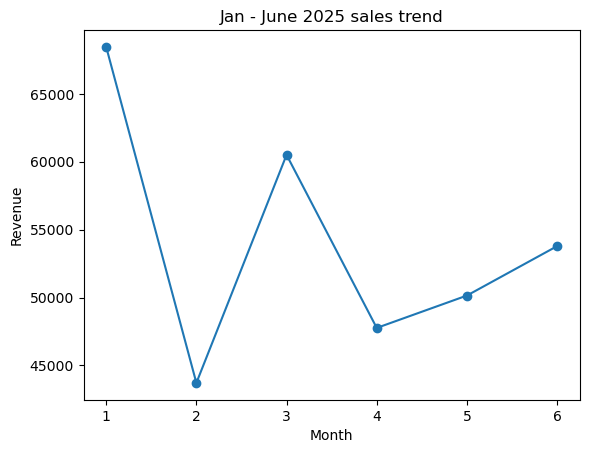

In [263]:
plt.plot(monthly_sales.index, monthly_sales["total_amount"], marker = 'o')
plt.title("Jan - June 2025 sales trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()